<div style="text-align:center; padding:15px; color:black; margin:0; font-size:250%; font-family:'Times New Roman'; background-color:#FFB6C1; border-bottom:4px solid black; overflow:hidden">
    <b>User Behavior Data Analysis</b>
</div>

This dataset provides a comprehensive analysis of mobile device usage patterns and user behavior classification. It contains 700 samples of user data, including metrics such as app usage time, screen-on time, battery drain, and data consumption. Each entry is categorized into one of five user behavior classes, ranging from light to extreme usage, allowing for insightful analysis and modeling.


## Key Features:

* User ID: Unique identifier for each user.
* Device Model: Model of the user's smartphone.
* Operating System: The OS of the device (iOS or Android).
* App Usage Time: Daily time spent on mobile applications, measured in minutes.
* Screen On Time: Average hours per day the screen is active.
* Battery Drain: Daily battery consumption in mAh.
* Number of Apps Installed: Total apps available on the device.
* Data Usage: Daily mobile data consumption in megabytes.
* Age: Age of the user.
* Gender: Gender of the user (Male or Female).
* User Behavior Class: Classification of user behavior based on usage patterns (1 to 5).

<div style="text-align:left; padding:15px; color:black; margin:0; font-size:150%; font-family:'Georgia'; background-color:#FFFACD; border:2px solid #9A8C98; overflow:hidden">
    <b>Import libraries</b>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

<div style="text-align:left; padding:15px; color:black; margin:0; font-size:150%; font-family:'Georgia'; background-color:#FFFACD; border:2px solid #9A8C98; overflow:hidden">
    <b>Load dataset</b>
</div>

In [8]:
df = pd.read_csv("user_behavior_dataset.csv")
df

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3
...,...,...,...,...,...,...,...,...,...,...,...
695,696,iPhone 12,iOS,92,3.9,1082,26,381,22,Male,2
696,697,Xiaomi Mi 11,Android,316,6.8,1965,68,1201,59,Male,4
697,698,Google Pixel 5,Android,99,3.1,942,22,457,50,Female,2
698,699,Samsung Galaxy S21,Android,62,1.7,431,13,224,44,Male,1


<div style="text-align:center; padding:15px; color:black; margin:0; font-size:150%; font-family:'Georgia'; background-color:#FFFACD; border:2px solid #9A8C98; overflow:hidden">
    <b>EDA : Exploratory Data Analysis</b>
</div>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User ID                     700 non-null    int64  
 1   Device Model                700 non-null    object 
 2   Operating System            700 non-null    object 
 3   App Usage Time (min/day)    700 non-null    int64  
 4   Screen On Time (hours/day)  700 non-null    float64
 5   Battery Drain (mAh/day)     700 non-null    int64  
 6   Number of Apps Installed    700 non-null    int64  
 7   Data Usage (MB/day)         700 non-null    int64  
 8   Age                         700 non-null    int64  
 9   Gender                      700 non-null    object 
 10  User Behavior Class         700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB


In [4]:
df.describe()

,User ID,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,User Behavior Class
count,700.00000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,350.50000,271.128571,5.272714,1525.158571,50.681429,929.742857,38.482857,2.990000
std,202.21688,177.199484,3.068584,819.136414,26.943324,640.451729,12.012916,1.401476
min,1.00000,30.000000,1.000000,302.000000,10.000000,102.000000,18.000000,1.000000
25%,175.75000,113.250000,2.500000,722.250000,26.000000,373.000000,28.000000,2.000000
50%,350.50000,227.500000,4.900000,1502.500000,49.000000,823.500000,38.000000,3.000000
75%,525.25000,434.250000,7.400000,2229.500000,74.000000,1341.000000,49.000000,4.000000
max,700.00000,598.000000,12.000000,2993.000000,99.000000,2497.000000,59.000000,5.000000


In [5]:
df.describe(include = 'object')

,Device Model,Operating System,Gender
count,700,700,700
unique,5,2,2
top,Xiaomi Mi 11,Android,Male
freq,146,554,364


In [36]:
df.columns

Index(['User ID', 'Device Model', 'Operating System',
       'App Usage Time (min/day)', 'Screen On Time (hours/day)',
       'Battery Drain (mAh/day)', 'Number of Apps Installed',
       'Data Usage (MB/day)', 'Age', 'Gender', 'User Behavior Class'],
      dtype='object')

<div style="text-align:center; padding:15px; color:black; margin:0; font-size:180%; font-family:'Georgia'; background-color:#FFFACD; border:2px solid black; overflow:hidden">
    <b>Count of Users by Device Model</b>
</div>

In [6]:
df['Device Model'].value_counts()

Device Model
Xiaomi Mi 11          146
iPhone 12             146
Google Pixel 5        142
OnePlus 9             133
Samsung Galaxy S21    133
Name: count, dtype: int64

In [16]:
df['Device Model'].value_counts().head(3).index

Index(['Xiaomi Mi 11', 'iPhone 12', 'Google Pixel 5'], dtype='object', name='Device Model')

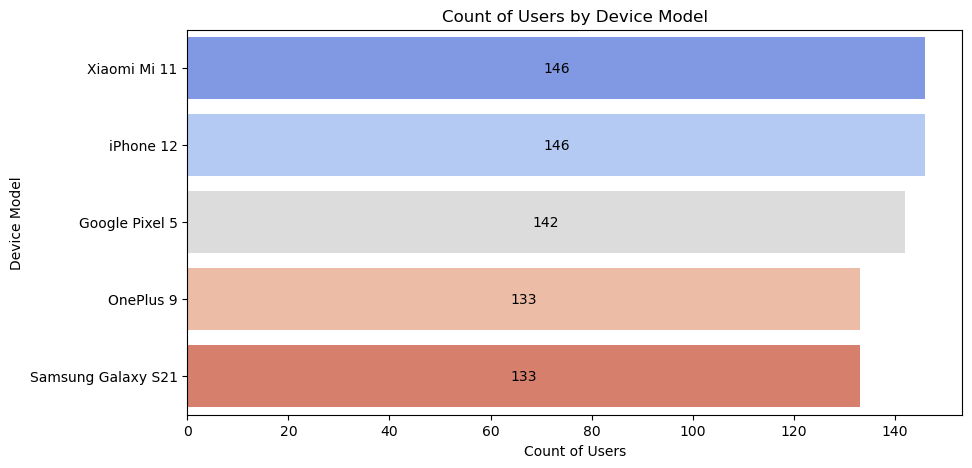

In [7]:
plt.figure(figsize = (10,5))
fig = sns.countplot(y = 'Device Model', data = df, order = df['Device Model'].value_counts().index, palette = 'coolwarm')

## Add counts on top of each bar
for container in fig.containers:
    fig.bar_label(container, label_type="center", color = 'black')
    
plt.title('Count of Users by Device Model')
plt.xlabel('Count of Users')
plt.ylabel('Device Model')
plt.show()

* By analyzing this diagram, we can find that 'Xiaomi Mi 11' and 'iPhone 12' users are more.

<div style="text-align:center; padding:15px; color:black; margin:0; font-size:180%; font-family:'Georgia'; background-color:#FFFACD; border:2px solid black; overflow:hidden">
    <b>Distribution of Operating Systems</b>
</div>

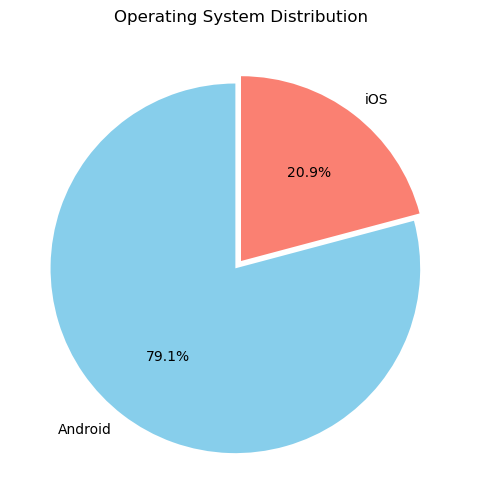

In [39]:
plt.figure(figsize=(8, 6))
df['Operating System'].value_counts().plot.pie(autopct='%0.1f%%', colors=['skyblue', 'salmon'], startangle=90, explode=[0.05, 0])
plt.title('Operating System Distribution')
plt.ylabel('')
plt.show()

* Android users are far more than iOS users

<div style="text-align:center; padding:15px; color:black; margin:0; font-size:180%; font-family:'Georgia'; background-color:#FFFACD; border:2px solid black; overflow:hidden">
    <b>Distribution of Gender</b>
</div>

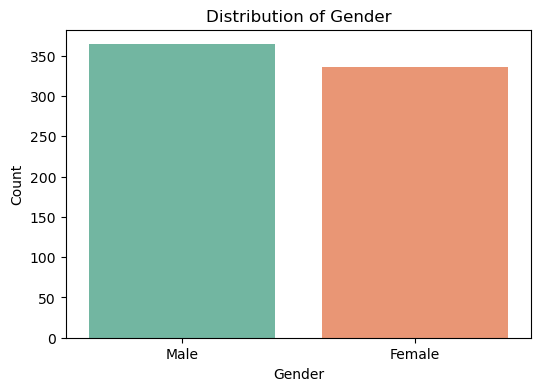

In [27]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df, palette='Set2')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

* This dataset consist of more Male users than Female users. But the difference is minute.

<div style="text-align:center; padding:15px; color:black; margin:0; font-size:180%; font-family:'Georgia'; background-color:#FFFACD; border:2px solid black; overflow:hidden">
    <b>App Usage Time vs. Screen On Time</b>
</div>

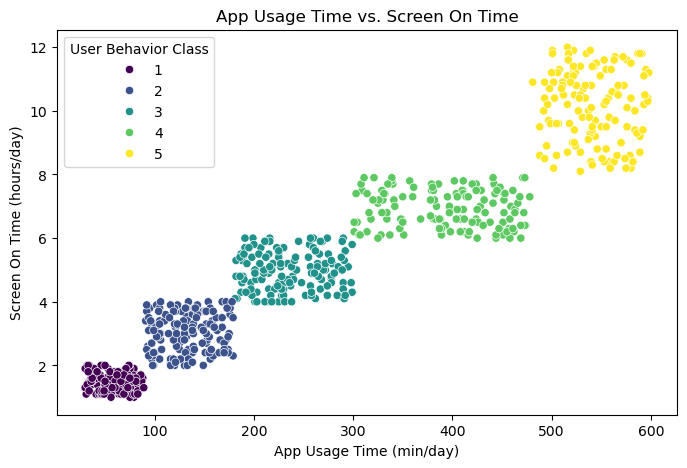

In [69]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='App Usage Time (min/day)', 
    y='Screen On Time (hours/day)',  
    hue='User Behavior Class',
    palette='viridis'
)
plt.title('App Usage Time vs. Screen On Time')
plt.xlabel('App Usage Time (min/day)')
plt.ylabel('Screen On Time (hours/day)')
plt.legend(title='User Behavior Class')
plt.show()

* From this figure,
    * class 5 : which consist of users with high screen on time and app usage time.
    * class 1 : which consist of users with low screen on time and app usage time.
    * This diagram shows that, the relationship between 'screen on time' and 'app usage time' is linear for all classes.

<div style="text-align:center; padding:15px; color:black; margin:0; font-size:180%; font-family:'Georgia'; background-color:#FFFACD; border:2px solid black; overflow:hidden">
    <b>Battery Drain vs. Data Usage</b>
</div>

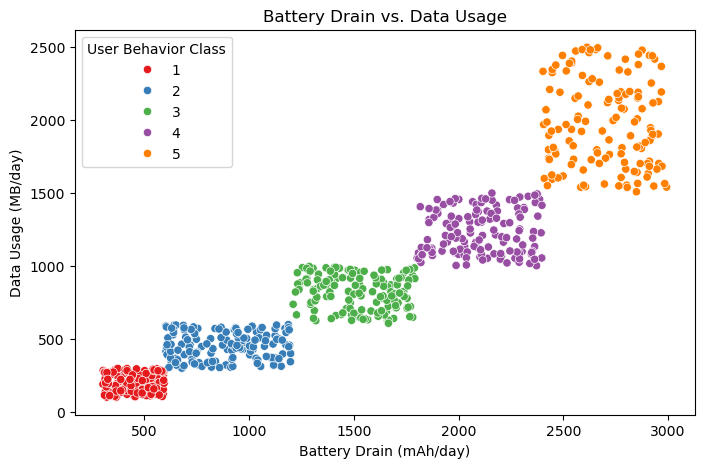

In [78]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Battery Drain (mAh/day)', y='Data Usage (MB/day)', hue='User Behavior Class', palette='Set1')
plt.title('Battery Drain vs. Data Usage')
plt.xlabel('Battery Drain (mAh/day)')
plt.ylabel('Data Usage (MB/day)')
plt.show()

* The relationship between Battery Drain and Data Usage is linear.

<div style="text-align:center; padding:15px; color:black; margin:0; font-size:180%; font-family:'Georgia'; background-color:#FFFACD; border:2px solid black; overflow:hidden">
    <b>Age vs. Data Usage</b>
</div>

In [85]:
df['Age'].max()

59

In [87]:
df['Age'].min()

18

In [37]:
# This is a list defining the boundaries of the bins.
age_bins = [18, 20, 30, 40, 50, 60]
labels = ('18-20','21-30','31-40','41-50','51-60')

# Create a new column for age groups
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=labels, right = True)

# The pd.cut function in pandas is used to segment and sort continuous data into discrete intervals or bins. 
# right = True : If you want 18-20 to include 20, ensure right=True

In [39]:
df.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class,Age Group
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4,31-40
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3,41-50
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2,41-50
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3,18-20
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3,31-40


In [41]:
# Calculate average data usage per age group
avg_data_usage = df.groupby('Age Group')['Data Usage (MB/day)'].mean().reset_index()
avg_data_usage

,Age Group,Data Usage (MB/day)
0,18-20,967.827586
1,21-30,893.837079
2,31-40,958.065476
3,41-50,918.406452
4,51-60,939.364780


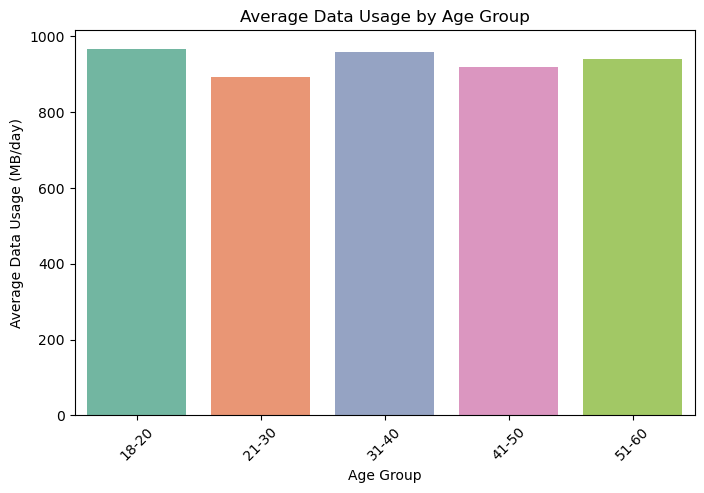

In [43]:
plt.figure(figsize=(8, 5))
sns.barplot(data=avg_data_usage, x='Age Group', y='Data Usage (MB/day)', palette='Set2')
plt.title('Average Data Usage by Age Group')
plt.ylabel('Average Data Usage (MB/day)')
plt.xlabel('Age Group')
plt.xticks(rotation=45)
plt.show()

* This diagram shows that
    * Users belongs to the age group 18-20 is using more data per day compared to other age groups.
    * Users belongs to the age group 21-30 is using least data per day compared to other age groups.

<div style="text-align:center; padding:15px; color:black; margin:0; font-size:180%; font-family:'Georgia'; background-color:#FFFACD; border:2px solid black; overflow:hidden">
    <b>Average Screen On Time by Gender</b>
</div>

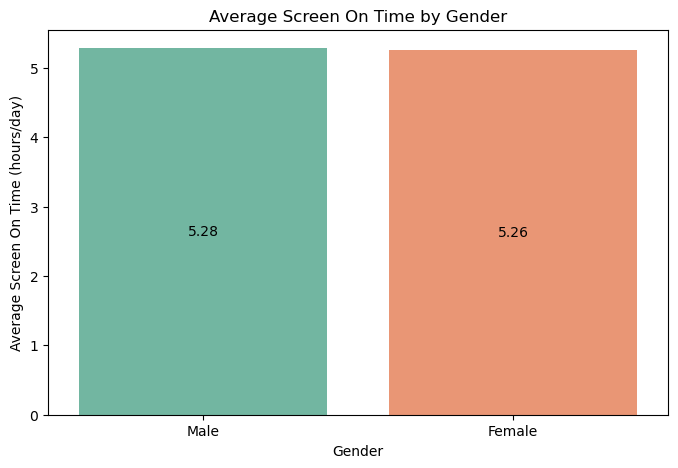

In [43]:
plt.figure(figsize=(8, 5))
fig = sns.barplot(x='Gender', y='Screen On Time (hours/day)', data=df, palette='Set2', ci=None)

# Add title and axis labels
plt.title('Average Screen On Time by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Screen On Time (hours/day)')

# for container in fig.containers:
#     fig.bar_label(container, label_type="center", color = 'black', labels=[f'{v.get_height():.2f}' for v in container])

## Add counts on top of each bar
for container in fig.containers:
    fig.bar_label(container, label_type="edge", color = 'black')

plt.show()

* From the figure,
    * Average screen on time for male and female are almost equal.
    * Screen on time of male users is more than the screen on time of female users by 0.02 units.

<div style="text-align:center; padding:15px; color:black; margin:0; font-size:180%; font-family:'Georgia'; background-color:#FFFACD; border:2px solid black; overflow:hidden">
    <b>User Behavior Class by Operating System</b>
</div>

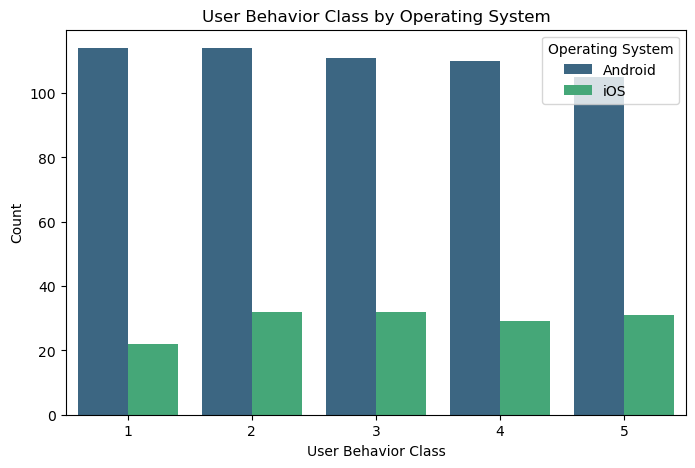

In [122]:
plt.figure(figsize=(8, 5))
sns.countplot(x='User Behavior Class', hue='Operating System', data=df, palette='viridis')
plt.title('User Behavior Class by Operating System')
plt.xlabel('User Behavior Class')
plt.ylabel('Count')
plt.legend(title='Operating System')
plt.show()

* For all the classes, users use Android operating system more when compared with iOS.

<div style="text-align:center; padding:15px; color:black; margin:0; font-size:180%; font-family:'Georgia'; background-color:#FFFACD; border:2px solid black; overflow:hidden">
    <b>User Behavior Class by Gender</b>
</div>

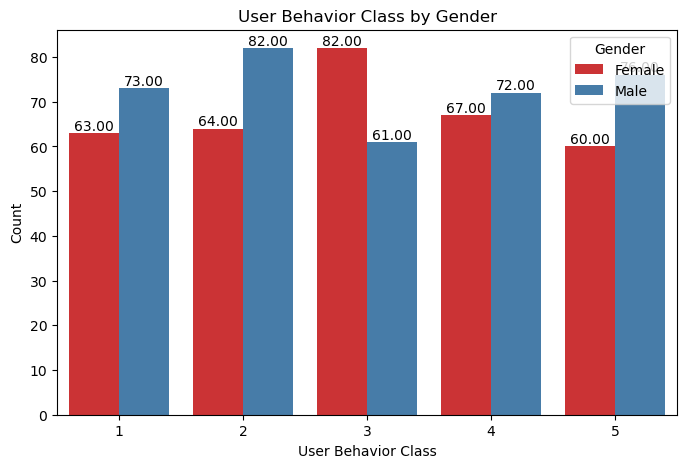

In [47]:
plt.figure(figsize=(8, 5))
fig = sns.countplot(x='User Behavior Class', hue='Gender', data=df, palette='Set1')
## Add counts on top of each bar
for container in fig.containers:
    fig.bar_label(container, label_type="edge", color = 'black')
 
plt.title('User Behavior Class by Gender')
plt.xlabel('User Behavior Class')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.show()

* From the figure,
    * Count of male users are more for almost all classes except class 3.
    * There is not that much difference in count of male and female users for all the classes.

<div style="text-align:center; padding:15px; color:black; margin:0; font-size:180%; font-family:'Georgia'; background-color:#FFFACD; border:2px solid black; overflow:hidden">
    <b>Joint Plot of App Usage Time and Battery Drain</b>
</div>

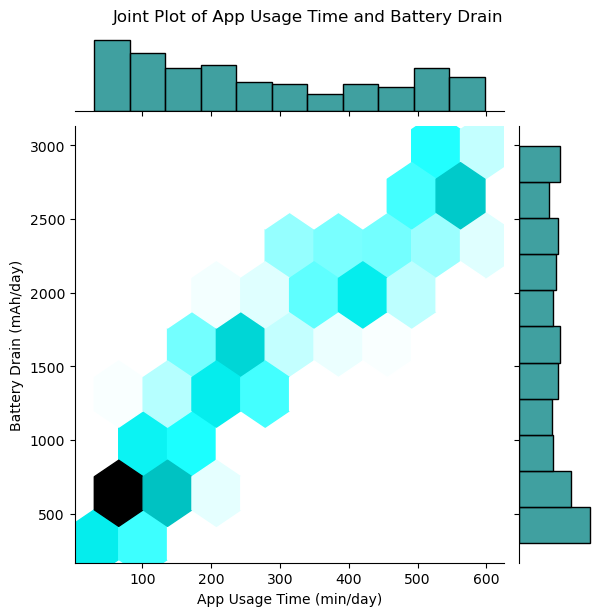

In [142]:
sns.jointplot(x='App Usage Time (min/day)', y='Battery Drain (mAh/day)', data=df, kind='hex', color='teal')
plt.suptitle('Joint Plot of App Usage Time and Battery Drain', y=1.02)
plt.show()

* The relationship between App Usage Time and Battery Drain is linear.

<div style="text-align:center; padding:15px; color:black; margin:0; font-size:180%; font-family:'Georgia'; background-color:#FFFACD; border:2px solid #9A8C98; overflow:hidden">
    <b>Data Usage by Gender</b>
</div>

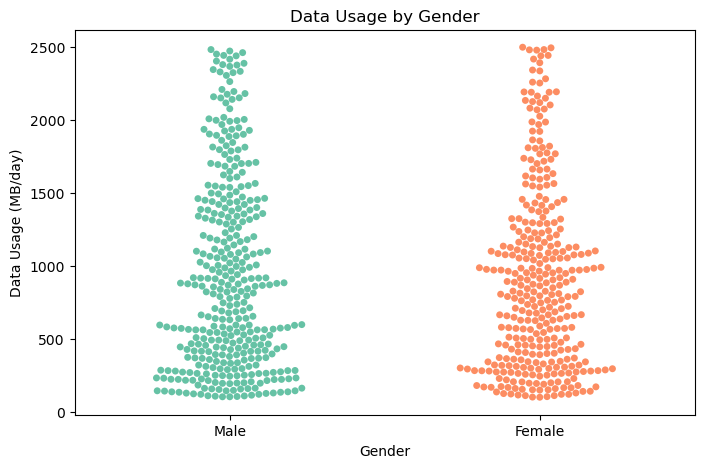

In [147]:
plt.figure(figsize=(8, 5))
sns.swarmplot(x='Gender', y='Data Usage (MB/day)', data=df, palette='Set2')
plt.title('Data Usage by Gender')
plt.xlabel('Gender')
plt.ylabel('Data Usage (MB/day)')
plt.show()

* Data usage of male anf female customers are almost equal.

<div style="text-align:center; padding:15px; color:black; margin:0; font-size:180%; font-family:'Georgia'; background-color:#FFFACD; border:2px solid black; overflow:hidden">
    <b>Average Battery Drain by Device Model</b>
</div>

In [156]:
avg_battery = df.groupby('Device Model')['Battery Drain (mAh/day)'].mean().reset_index()
avg_battery

,Device Model,Battery Drain (mAh/day)
0,Google Pixel 5,1475.676056
1,OnePlus 9,1523.849624
2,Samsung Galaxy S21,1504.571429
3,Xiaomi Mi 11,1528.876712
4,iPhone 12,1589.513699


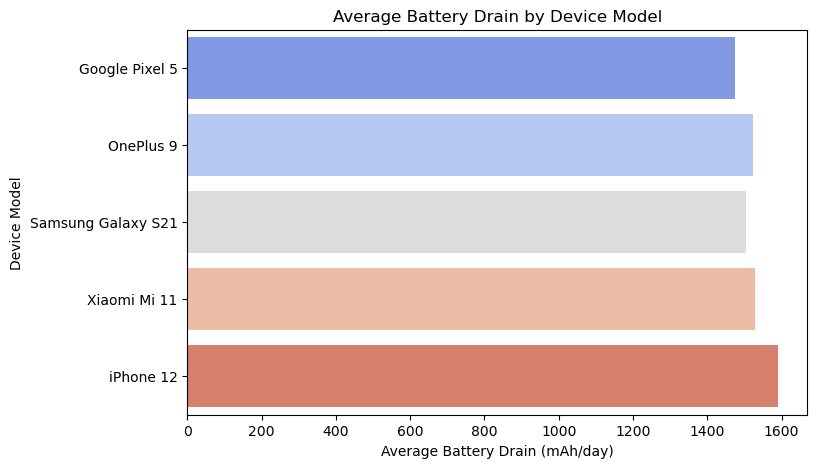

In [160]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Battery Drain (mAh/day)', y='Device Model', data = avg_battery, palette='coolwarm')
plt.title('Average Battery Drain by Device Model')
plt.xlabel('Average Battery Drain (mAh/day)')
plt.ylabel('Device Model')
plt.show()

* From this figure,
   * Average battery drain is high for iPhone 12 compared to other device models.
   * Average battery drain is low for Google Pixel 5 compared to other device models.

<div style="text-align:center; padding:15px; color:black; margin:0; font-size:180%; font-family:'Georgia'; background-color:#FFFACD; border:2px solid black; overflow:hidden">
    <b>Age vs. Average App Usage Time</b>
</div>

In [177]:
age_usage = df.groupby('Age')['App Usage Time (min/day)'].mean().reset_index()
age_usage

,Age,App Usage Time (min/day)
0,18,264.272727
1,19,248.583333
2,20,282.764706
3,21,332.352941
4,22,344.708333
5,23,282.533333
6,24,278.857143
7,25,238.000000
8,26,216.500000
9,27,251.958333


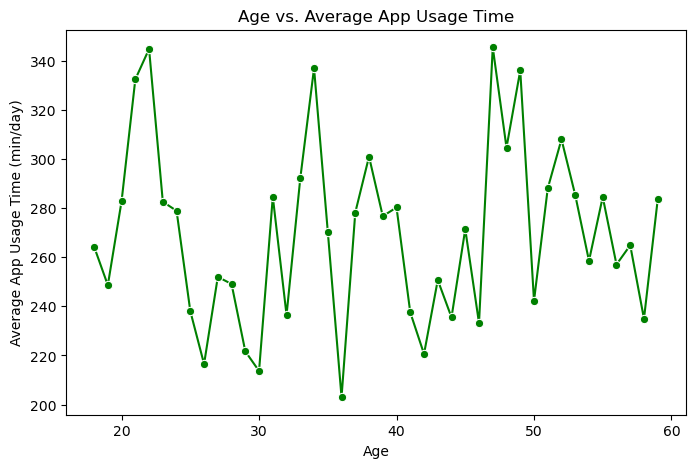

In [181]:
plt.figure(figsize=(8, 5))
sns.lineplot(x='Age', y='App Usage Time (min/day)', data=age_usage, marker='o', color='green')
plt.title('Age vs. Average App Usage Time')
plt.xlabel('Age')
plt.ylabel('Average App Usage Time (min/day)')
plt.show()

<div style="text-align:center; padding:15px; color:black; margin:0; font-size:180%; font-family:'Georgia'; background-color:#FFFACD; border:2px solid black; overflow:hidden">
    <b>Screen On Time Distribution by Gender</b>
</div>

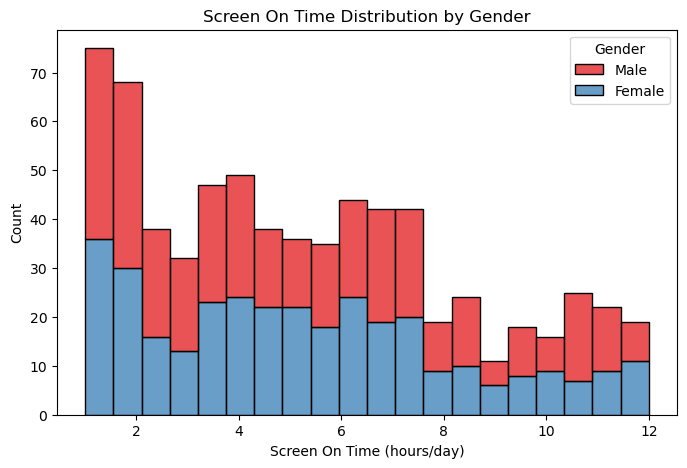

In [184]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Screen On Time (hours/day)', hue='Gender', multiple='stack', palette='Set1', bins=20)
plt.title('Screen On Time Distribution by Gender')
plt.xlabel('Screen On Time (hours/day)')
plt.ylabel('Count')
plt.show()